# YOLO26 — 스마트 제조 설비·안전 모니터링

[AI Hub 스마트 제조 시설 안전 감시 데이터](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71679) 샘플을 이용해  
**Ultralytics YOLO26**로 사람·설비 객체 탐지 모델을 학습하고, CCTV 영상에서 실시간 모니터링하는 예제입니다.

| 항목 | 설명 |
|------|------|
| 데이터 | `smart_factory_human_accident.zip` (인명사고·끼임 샘플) |
| 클래스 | human, molding-machine, milling-machine, injection-machine |
| 모델 | **YOLO26s** (`yolo26s.pt`) |
| 선행 EDA | `12_SmartFactory_EDA.ipynb` |

## 0. 환경 설정

In [1]:
# %pip install -U ultralytics opencv-python-headless

import sys
from pathlib import Path

import torch
import yaml
from IPython.display import Image, display, Video
from ultralytics import YOLO, __version__

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DEVICE = 0 if torch.cuda.is_available() else "cpu"

ROOT = Path("/content") if IN_COLAB else Path.cwd()
if not (ROOT / "smart_factory_human_accident.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "smart_factory_human_accident.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "smart_factory_human_accident.zip"
DATA_ROOT = ROOT / "smart_factory"
YOLO_DIR = ROOT / "smart_factory_yolo"
YAML_PATH = YOLO_DIR / "smart_factory.yaml"

RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"

MODEL_NAME = "yolo26s.pt"
# YOLO26 소규모 데이터셋은 confidence가 낮게 나옴 → 0.25면 탐지 0건
CONF_THRESH = 0.10
EXPERIMENT = "yolo26_smart_factory_v2"

print(f"환경       : {'Colab' if IN_COLAB else '로컬'}")
print(f"Ultralytics: {__version__}")
print(f"Device     : {DEVICE}")
print(f"ROOT       : {ROOT.resolve()}")

환경       : 로컬
Ultralytics: 8.4.46
Device     : 0
ROOT       : C:\MyCursorLab\06_Object_Detection


## 1. 데이터 준비 (압축 해제 + YOLO 변환)

In [2]:
import json
import shutil
import zipfile

# 80장 소규모 샘플 → 2클래스(human/facility)가 4클래스보다 학습 안정적
CLASS_NAMES = ["human", "facility"]
HUMAN_CLASS_ID, FACILITY_CLASS_ID = 0, 1
VAL_VIDEO_STEMS = {"human-accident_jam_rgb_1069_cctv4"}


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    pngs = [p for p in root.rglob("*.png") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(pngs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    candidates = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (
        max(candidates, key=lambda p: len(list(p.rglob("*.png")))),
        max(candidates, key=lambda p: len(list(p.rglob("*.json")))),
    )


def seg_to_bbox_xywh(segmentation: list[float]) -> tuple[float, float, float, float]:
    xs, ys = segmentation[0::2], segmentation[1::2]
    return min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)


def coco_to_yolo(x, y, w, h, img_w, img_h):
    return (x + w / 2) / img_w, (y + h / 2) / img_h, w / img_w, h / img_h


def prepare_yolo_dataset(root: Path, output_dir: Path) -> dict:
    raw_root, label_root = find_raw_and_label_roots(root)
    for split in ("train", "val"):
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    stats = {"train": 0, "val": 0, "skipped": 0}
    for json_path in sorted(label_root.rglob("*.json")):
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        if "annotations" not in data:
            continue
        meta = data["meta_information"]
        rel = json_path.parent.relative_to(label_root)
        split = "val" if rel.parts[-1] in VAL_VIDEO_STEMS else "train"
        src_img = raw_root / rel / meta["file_name"]
        if not src_img.exists():
            stats["skipped"] += 1
            continue

        stem = Path(meta["file_name"]).stem
        dst_img = output_dir / "images" / split / f"{stem}.png"
        dst_lbl = output_dir / "labels" / split / f"{stem}.txt"
        shutil.copy2(src_img, dst_img)

        lines = []
        for ann in data["annotations"]:
            obj_id = ann.get("id", "")
            if obj_id.startswith("h") and ann.get("segmentation"):
                x, y, w, h = seg_to_bbox_xywh(ann["segmentation"])
                xc, yc, nw, nh = coco_to_yolo(x, y, w, h, int(meta["width"]), int(meta["height"]))
                lines.append(f"{HUMAN_CLASS_ID} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            elif obj_id.startswith("m") and ann.get("bbox"):
                x, y, w, h = ann["bbox"]
                xc, yc, nw, nh = coco_to_yolo(x, y, w, h, int(meta["width"]), int(meta["height"]))
                lines.append(f"{FACILITY_CLASS_ID} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
        dst_lbl.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
        stats[split] += 1

    YAML_PATH.write_text(
        f"path: {output_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names:\n" + "".join(f"  - {n}\n" for n in CLASS_NAMES),
        encoding="utf-8",
    )
    stats["yaml"] = str(YAML_PATH)
    return stats


need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)

# 클래스 변경 시 이전 cache 삭제 (학습 오류 방지)
for cache in YOLO_DIR.rglob("*.cache"):
    cache.unlink(missing_ok=True)

stats = prepare_yolo_dataset(DATA_ROOT, YOLO_DIR)
print("YOLO 데이터셋:", stats)

cfg = yaml.safe_load(YAML_PATH.read_text(encoding="utf-8"))
print("클래스:", cfg["names"])
print(f"train 이미지: {len(list((YOLO_DIR / 'images/train').glob('*.png')))}")
print(f"val   이미지: {len(list((YOLO_DIR / 'images/val').glob('*.png')))}")

YOLO 데이터셋: {'train': 80, 'val': 20, 'skipped': 0, 'yaml': 'c:\\MyCursorLab\\06_Object_Detection\\smart_factory_yolo\\smart_factory.yaml'}
클래스: ['human', 'facility']
train 이미지: 80
val   이미지: 20


## 2. YOLO26 모델 학습

In [ ]:
# RTX 3060 기준 약 18분 소요
model = YOLO(MODEL_NAME)

results = model.train(
    data=str(YAML_PATH),
    epochs=150,
    imgsz=640,
    batch=8,
    device=DEVICE,
    name=EXPERIMENT,
    exist_ok=True,
    patience=100,
    # 소규모(80장) 2클래스 권장 설정
    lr0=0.001,
    mosaic=0.3,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=10,
    freeze=10,         # 소규모 데이터 과적합 완화
    workers=0,
    plots=True,
)

BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
print(f"최적 가중치: {BEST_WEIGHTS.resolve()}")
print(f"※ 추론 시 conf={CONF_THRESH} 사용 (YOLO26은 confidence가 낮게 출력되는 경향)")

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\MyCursorLab\06_Object_Detection\smart_factory_yolo\smart_factory.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, m

## 3. 검증 (Validation)

In [5]:
best_model = YOLO(str(BEST_WEIGHTS))
metrics = best_model.val(data=str(YAML_PATH), device=DEVICE)
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50    : {metrics.box.map50:.4f}")

# 추론 confidence 사전 점검
probe_img = str(sorted((YOLO_DIR / "images" / "val").glob("*.png"))[0])
probe = best_model.predict(probe_img, conf=0.01, verbose=False)[0]
top_conf = max((float(b.conf) for b in probe.boxes), default=0.0)
print(f"샘플 최고 conf: {top_conf:.3f}  (현재 CONF_THRESH={CONF_THRESH})")
if top_conf < CONF_THRESH:
    print("⚠ confidence가 낮습니다. CONF_THRESH를 0.05~0.10으로 낮추세요.")

Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1952.370.4 MB/s, size: 3093.4 KB)
val: Scanning C:\MyCursorLab\06_Object_Detection\smart_factory_yolo\labels\val.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.2s/it 4.3s<13.3s
                   all         20         40       0.64      0.925      0.913      0.643
                 human         20         20      0.571          1      0.995      0.915
              facility         20         20      0.708       0.85      0.831      0.372
Speed: 3.9ms preprocess, 16.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\val-10
mAP50-95: 0.6432
mAP50    : 0.9

## 4. 이미지 추론 — 설비·작업자 탐지

설비(facility) bbox가 크고 human+facility 동시 탐지가 잘 되는 **대표 3종 설비** 샘플로 추론합니다.


image 1/1 c:\MyCursorLab\06_Object_Detection\smart_factory_yolo\images\train\human-accident_jam_rgb_0957_cctv1_05.png: 384x640 1 human, 1 facility, 70.4ms
Speed: 6.0ms preprocess, 70.4ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\human-accident_jam_rgb_0957_cctv1_05
  설비종류(원본): molding-machine | 탐지 human=1, facility=1
    facility: conf=0.979
    human: conf=0.971

[molding-machine | human-accident_jam_rgb_0957_cctv1_05.png]


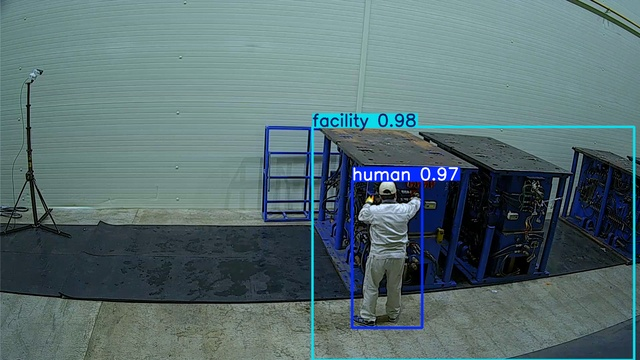

  저장 폴더: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\human-accident_jam_rgb_0957_cctv1_05

image 1/1 c:\MyCursorLab\06_Object_Detection\smart_factory_yolo\images\train\human-accident_jam_rgb_1048_cctv3_05.png: 384x640 1 human, 1 facility, 42.5ms
Speed: 5.9ms preprocess, 42.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\human-accident_jam_rgb_1048_cctv3_05
  설비종류(원본): milling-machine | 탐지 human=1, facility=1
    facility: conf=0.976
    human: conf=0.948

[milling-machine | human-accident_jam_rgb_1048_cctv3_05.png]


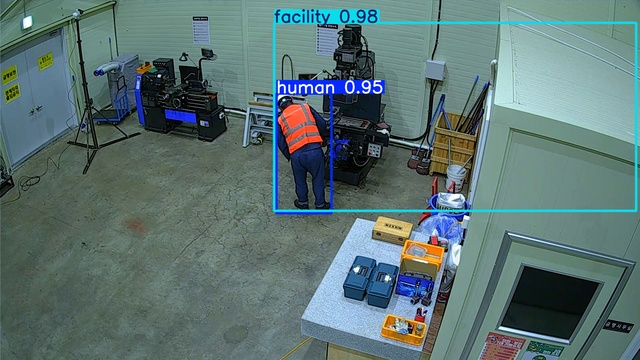

  저장 폴더: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\human-accident_jam_rgb_1048_cctv3_05

image 1/1 c:\MyCursorLab\06_Object_Detection\smart_factory_yolo\images\train\human-accident_jam_rgb_2031_cctv3_05.png: 384x640 1 human, 1 facility, 13.3ms
Speed: 2.0ms preprocess, 13.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\human-accident_jam_rgb_2031_cctv3_05
  설비종류(원본): injection-machine | 탐지 human=1, facility=1
    human: conf=0.956
    facility: conf=0.824

[injection-machine | human-accident_jam_rgb_2031_cctv3_05.png]


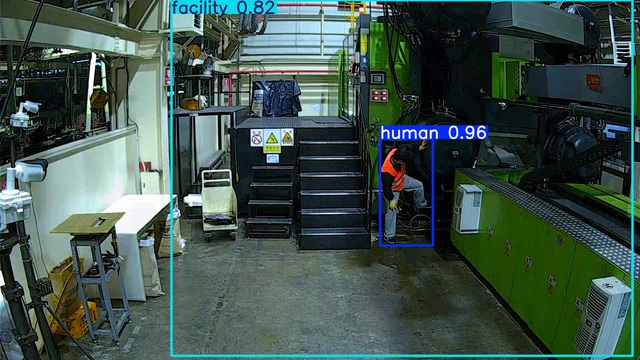

  저장 폴더: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\human-accident_jam_rgb_2031_cctv3_05


In [10]:
import cv2
from io import BytesIO
from PIL import Image as PILImage

PREDICT_DIR = ROOT / "runs" / "detect" / f"{EXPERIMENT}_predict"


def show_result_image(result, title: str = "", width: int = 640) -> None:
    """탐지 결과 이미지를 노트북 셀에 출력 (Windows 경로 이슈 회피)."""
    plotted = result.plot()  # BGR numpy (bbox·클래스명 오버레이)
    rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(rgb)
    if width and pil_img.width > width:
        ratio = width / pil_img.width
        pil_img = pil_img.resize((width, int(pil_img.height * ratio)), PILImage.LANCZOS)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=95)
    if title:
        print(f"\n[{title}]")
    display(Image(data=buf.getvalue(), width=width))


# val(cctv4)은 human만 잘 잡히는 경우가 많아, 설비 탐지가 검증된 train 샘플 사용
FACILITY_SAMPLE_STEMS = [
    ("molding-machine", "human-accident_jam_rgb_0957_cctv1_05"),
    ("milling-machine", "human-accident_jam_rgb_1048_cctv3_05"),
    ("injection-machine", "human-accident_jam_rgb_2031_cctv3_05"),
]


def resolve_yolo_image(stem: str) -> Path:
    for split in ("train", "val"):
        path = YOLO_DIR / "images" / split / f"{stem}.png"
        if path.exists():
            return path
    raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {stem}.png")


sample_images = [(fac, resolve_yolo_image(stem)) for fac, stem in FACILITY_SAMPLE_STEMS]
for facility_name, img_path in sample_images:
    preds = best_model.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        save=True,
        project=str(PREDICT_DIR),
        name=img_path.stem,
        exist_ok=True,
        device=DEVICE,
    )
    result = preds[0]
    if len(result.boxes) == 0:
        print(f"  ⚠ 탐지 0건 (conf={CONF_THRESH}) → 0.05로 재시도")
        result = best_model.predict(str(img_path), conf=0.05, device=DEVICE, verbose=False)[0]

    humans = sum(1 for b in result.boxes if result.names[int(b.cls)] == "human")
    facilities = sum(1 for b in result.boxes if result.names[int(b.cls)] == "facility")
    print(f"  설비종류(원본): {facility_name} | 탐지 human={humans}, facility={facilities}")
    for box in result.boxes:
        cls_name = result.names[int(box.cls)]
        print(f"    {cls_name}: conf={float(box.conf):.3f}")

    show_result_image(result, title=f"{facility_name} | {img_path.name}")
    saved = Path(result.save_dir) / img_path.name
    print(f"  저장 폴더: {Path(result.save_dir).resolve()}")
    if saved.exists():
        print(f"  저장 파일: {saved.resolve()}")

## 5. 영상 추론 — CCTV 설비 상태 모니터링

원본 MP4 영상에 YOLO26 탐지 결과를 오버레이하여 저장합니다.

모니터링 대상: human-accident_jam_rgb_0957_cctv1.mp4

video 1/1 (frame 1/429) c:\MyCursorLab\06_Object_Detection\smart_factory\01.\human-accident\jam\rgb\human-accident_jam_rgb_0957_cctv1\human-accident_jam_rgb_0957_cctv1.mp4: 384x640 1 human, 1 facility, 32.3ms
frame 000: human=1, facility=1
video 1/1 (frame 2/429) c:\MyCursorLab\06_Object_Detection\smart_factory\01.\human-accident\jam\rgb\human-accident_jam_rgb_0957_cctv1\human-accident_jam_rgb_0957_cctv1.mp4: 384x640 1 human, 1 facility, 30.9ms
frame 001: human=1, facility=1
video 1/1 (frame 3/429) c:\MyCursorLab\06_Object_Detection\smart_factory\01.\human-accident\jam\rgb\human-accident_jam_rgb_0957_cctv1\human-accident_jam_rgb_0957_cctv1.mp4: 384x640 1 human, 1 facility, 33.2ms
frame 002: human=1, facility=1
video 1/1 (frame 4/429) c:\MyCursorLab\06_Object_Detection\smart_factory\01.\human-accident\jam\rgb\human-accident_jam_rgb_0957_cctv1\human-accident_jam_rgb_0957_cctv1.mp4: 384x640 1 human, 1 facility, 28.0ms
video 1/1 (frame 5/429)

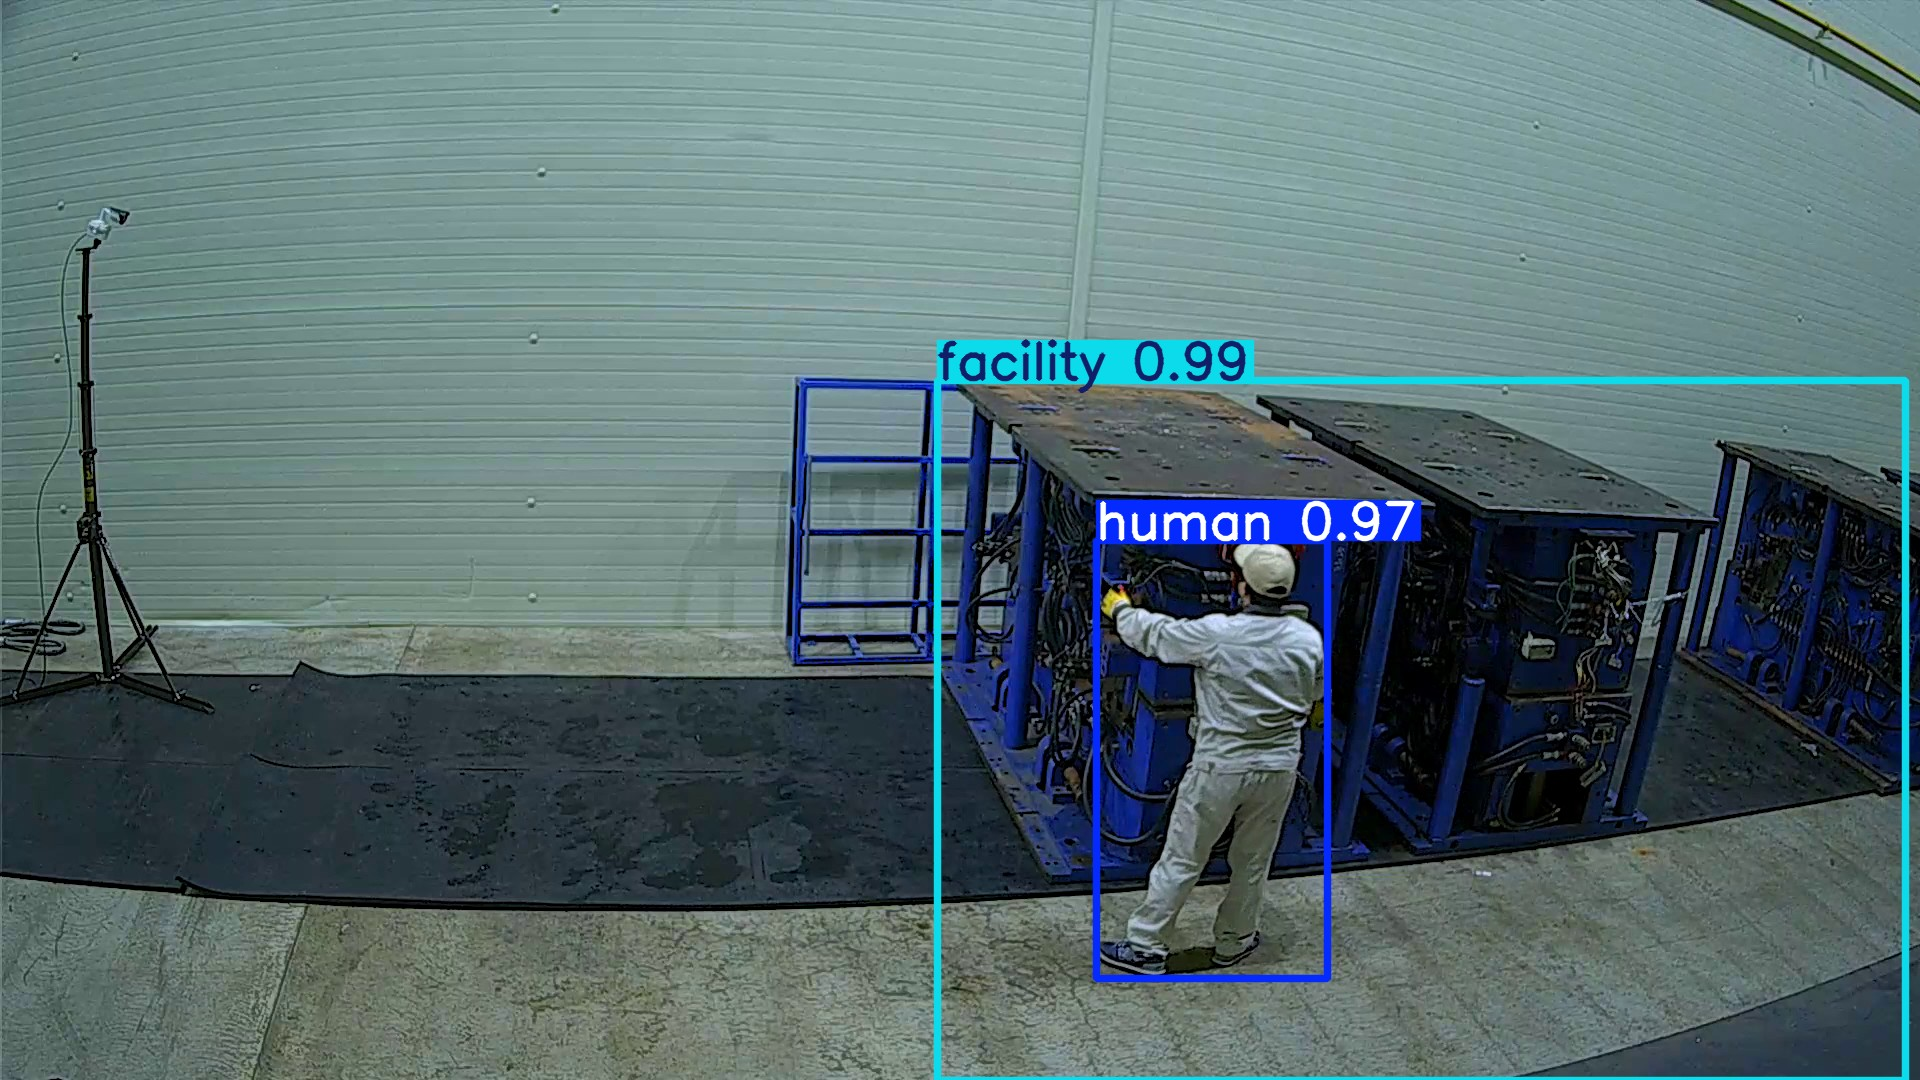

[샘플 frame 009]


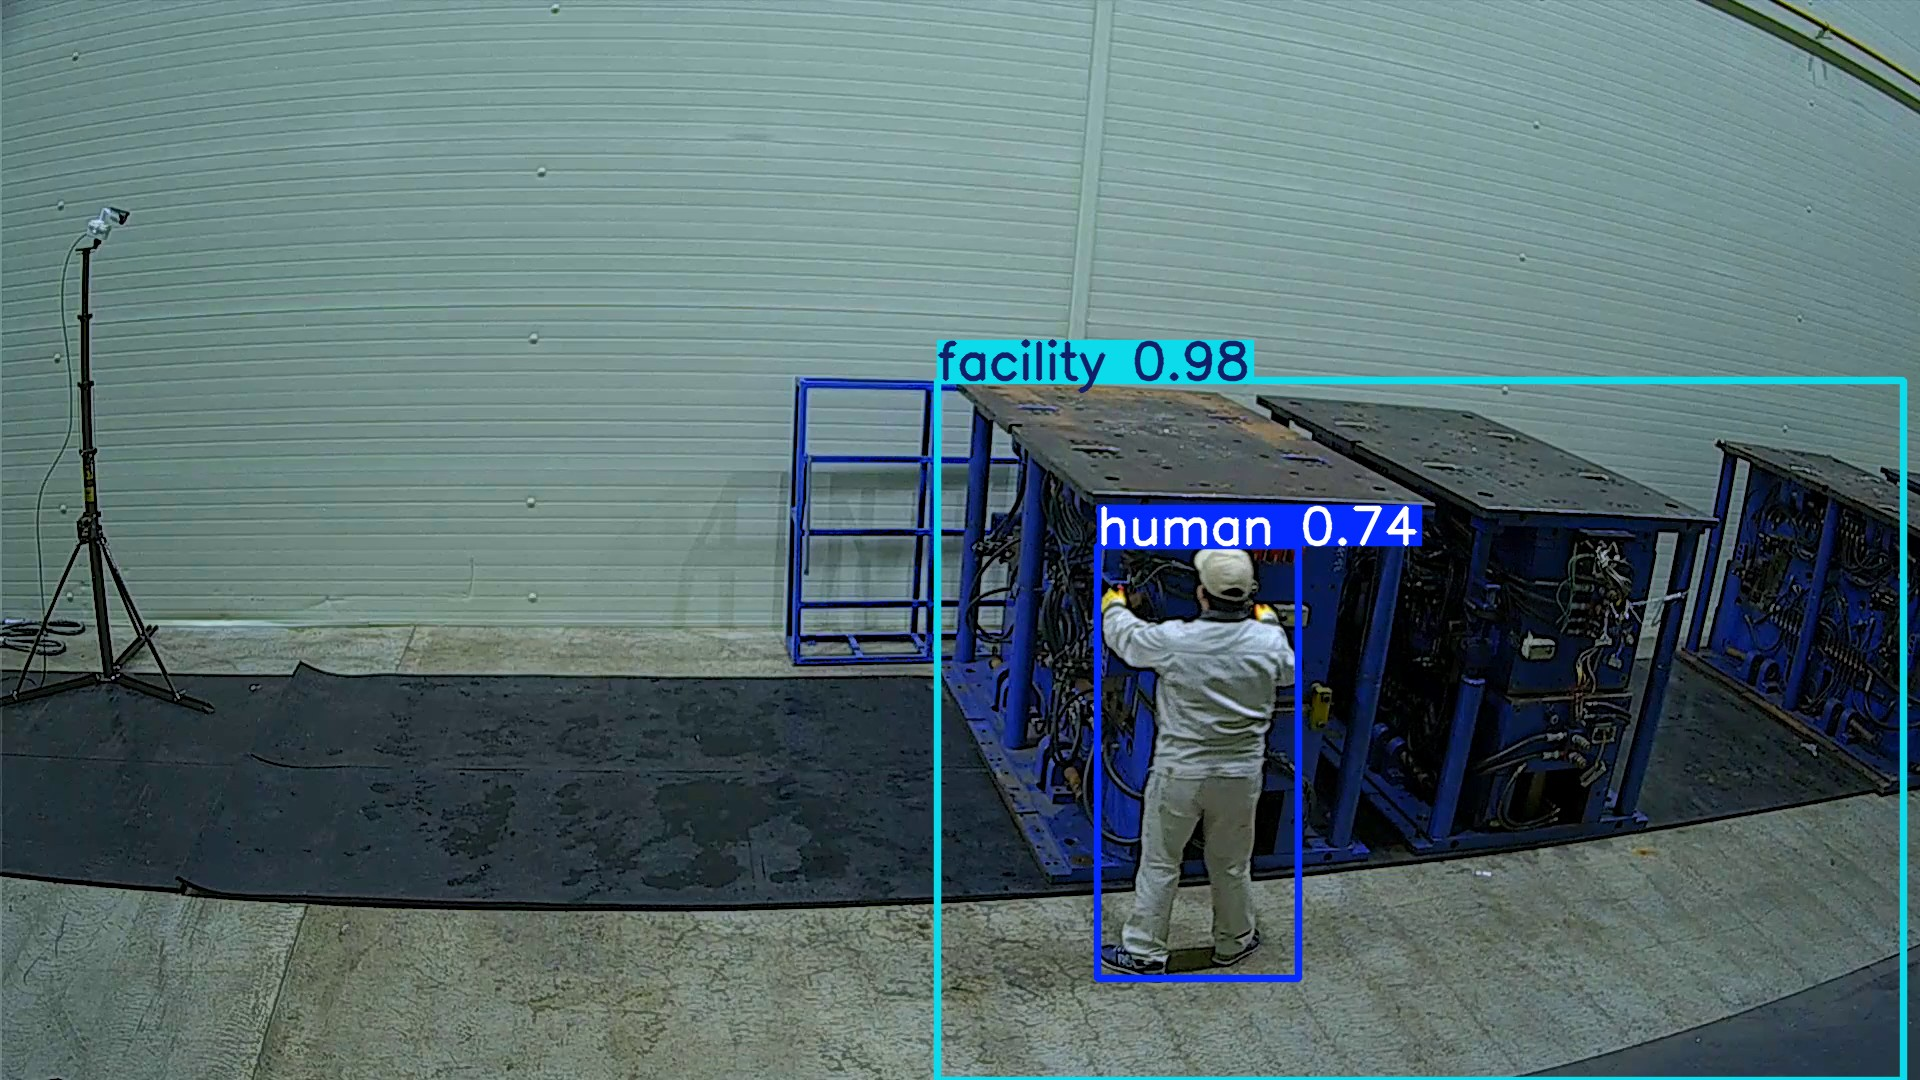

[샘플 frame 019]


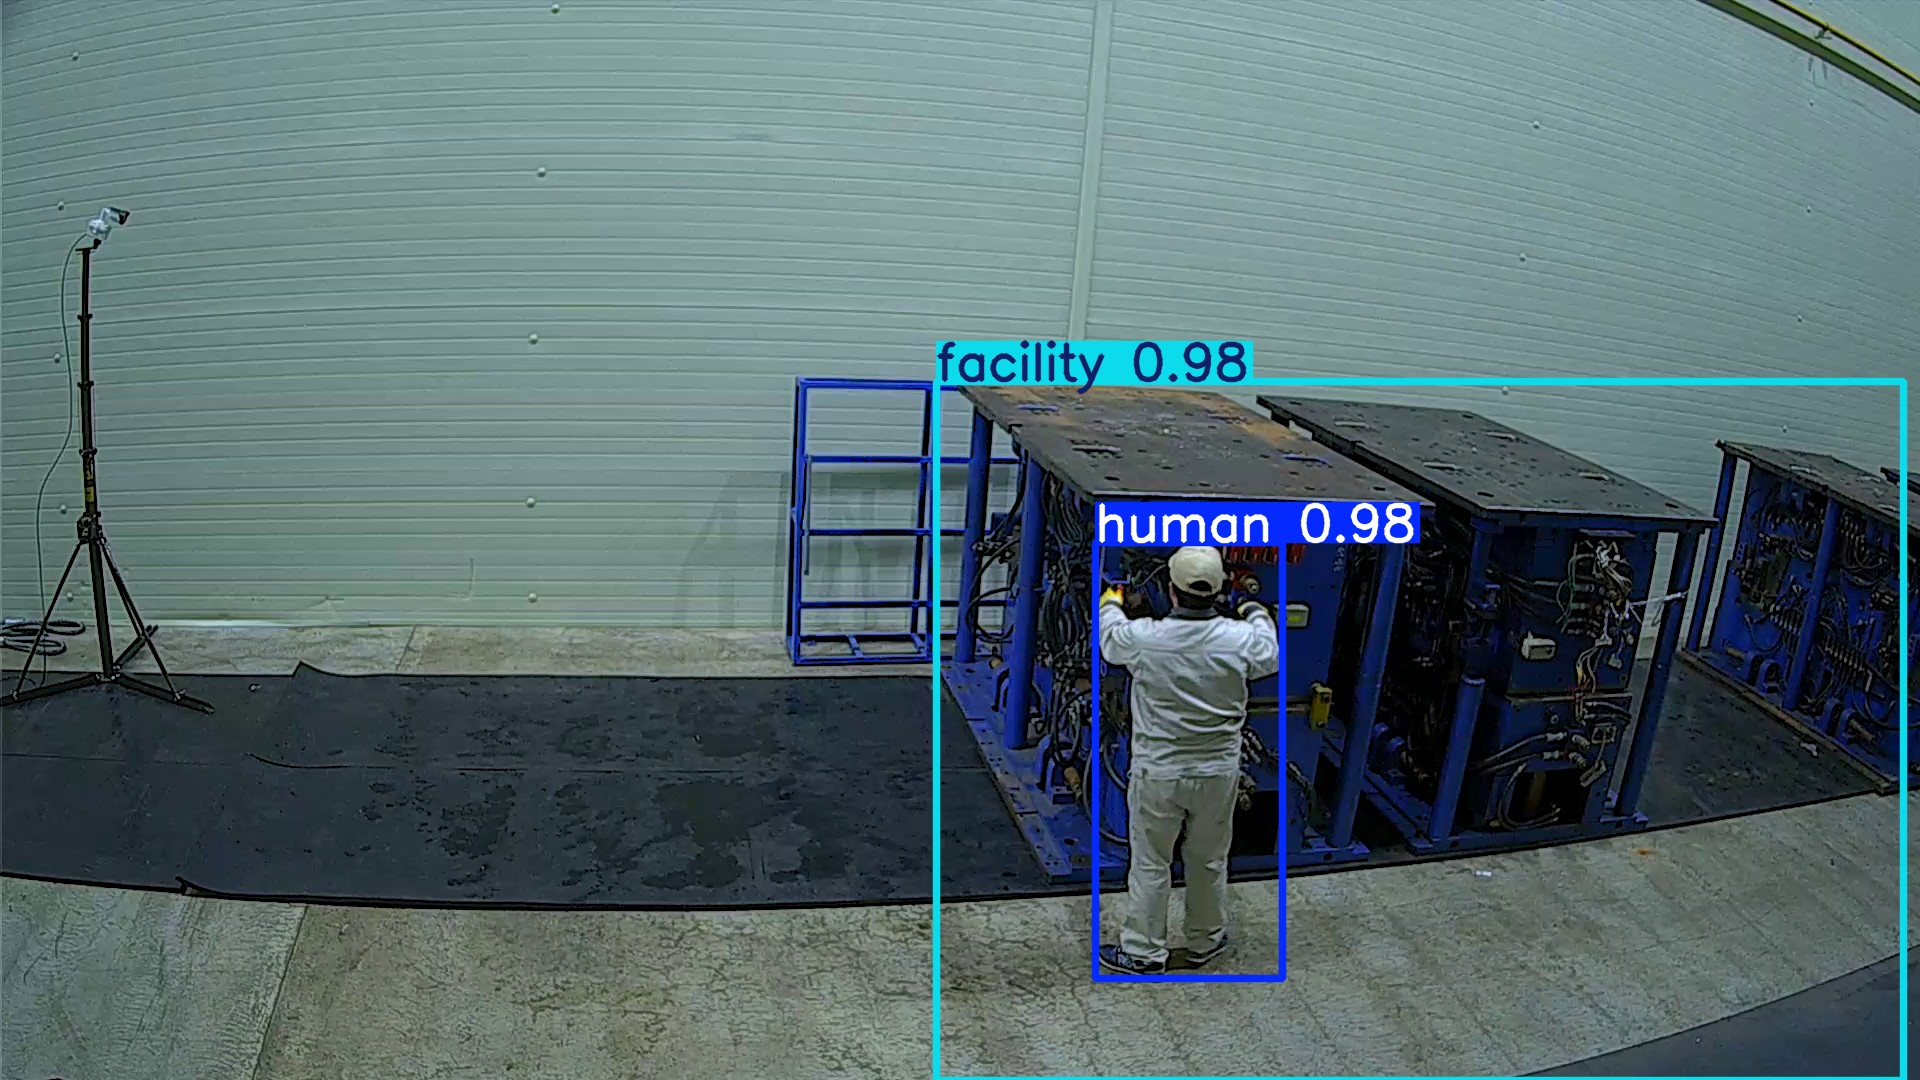


저장 파일: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\cctv_monitor\human-accident_jam_rgb_0957_cctv1.mp4 (.mp4)
노트북 미리보기 GIF: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_smart_factory_v2_predict\cctv_monitor\human-accident_jam_rgb_0957_cctv1.preview.gif


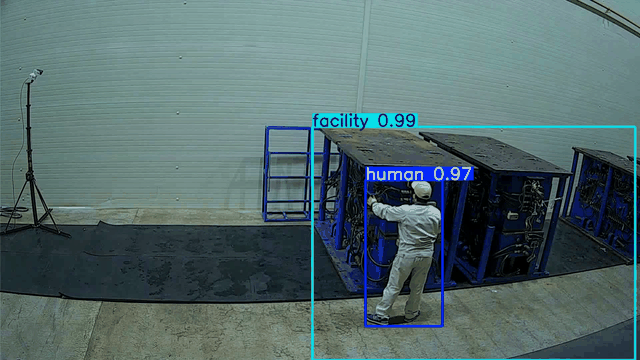

※ 전체 영상은 위 경로의 .avi/.mp4 파일을 탐색기에서 더블클릭해 재생하세요.


In [12]:
import cv2
from io import BytesIO
from IPython.display import HTML, Image, display
from PIL import Image as PILImage

raw_root, _ = find_raw_and_label_roots(DATA_ROOT)
video_files = sorted(raw_root.rglob("*.mp4"))
if not video_files:
    raise FileNotFoundError(f"MP4 영상을 찾을 수 없습니다: {raw_root}")
video_path = video_files[0]
print(f"모니터링 대상: {video_path.name}")

video_preds = best_model.predict(
    source=str(video_path),
    conf=CONF_THRESH,
    save=True,
    project=str(PREDICT_DIR),
    name="cctv_monitor",
    exist_ok=True,
    device=DEVICE,
    stream=True,
)

frame_alerts = 0
sample_frames: dict[int, object] = {}
last_result = None
for i, result in enumerate(video_preds):
    last_result = result
    humans = sum(1 for b in result.boxes if result.names[int(b.cls)] == "human")
    facilities = len(result.boxes) - humans
    if humans > 0:
        frame_alerts += 1
    if i < 3:
        print(f"frame {i:03d}: human={humans}, facility={facilities}")
    if i in (0, 9, 19):
        sample_frames[i] = result

print(f"\n총 프레임: {i + 1}, 작업자 감지 프레임: {frame_alerts}")

# ── 샘플 프레임 화면 출력 ──
for idx, result in sample_frames.items():
    plotted = result.plot()
    rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(rgb)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=90)
    print(f"[샘플 frame {idx:03d}]")
    display(Image(data=buf.getvalue(), width=640))

# ── 결과 영상 찾기 & 재생 ──
# Ultralytics(Windows)는 mp4 대신 .avi 로 저장하는 경우가 많음
def find_saved_video(search_dirs: list[Path]) -> Path | None:
    for folder in search_dirs:
        if not folder.exists():
            continue
        for ext in ("*.mp4", "*.avi", "*.mkv"):
            found = sorted(folder.rglob(ext))
            if found:
                return found[0]
    return None


def make_gif_preview(
    video_path: Path,
    gif_path: Path,
    every_n: int = 12,
    max_frames: int = 24,
    width: int = 640,
) -> Path:
    """노트북 브라우저에서 재생 가능한 GIF 미리보기 생성."""
    cap = cv2.VideoCapture(str(video_path))
    frames: list[PILImage.Image] = []
    idx = 0
    while len(frames) < max_frames:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % every_n == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil = PILImage.fromarray(rgb)
            if pil.width > width:
                ratio = width / pil.width
                pil = pil.resize((width, int(pil.height * ratio)), PILImage.LANCZOS)
            frames.append(pil)
        idx += 1
    cap.release()
    if not frames:
        raise RuntimeError(f"GIF 생성 실패: {video_path}")
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0,
    )
    return gif_path


out_video_dir = Path(last_result.save_dir) if last_result else PREDICT_DIR / "cctv_monitor"
saved_video = find_saved_video([out_video_dir, PREDICT_DIR / "cctv_monitor", PREDICT_DIR])

if saved_video:
    print(f"\n저장 파일: {saved_video.resolve()} ({saved_video.suffix})")
    gif_path = saved_video.with_suffix(".preview.gif")
    make_gif_preview(saved_video, gif_path)
    print(f"노트북 미리보기 GIF: {gif_path.resolve()}")
    with open(gif_path, "rb") as f:
        display(Image(data=f.read(), width=640))
    print("※ 전체 영상은 위 경로의 .avi/.mp4 파일을 탐색기에서 더블클릭해 재생하세요.")
else:
    print("저장된 영상을 찾지 못했습니다. 아래 폴더를 확인하세요:")
    print(out_video_dir.resolve())

## 6. CLI 참고 명령어

```bash
# 학습 (섹션 1에서 YOLO 데이터셋 변환 후 실행)
yolo detect train model=yolo26s.pt data=smart_factory_yolo/smart_factory.yaml epochs=100 imgsz=640 batch=8 device=0 name=yolo26_smart_factory

# 영상 모니터링 추론
yolo predict model=runs/detect/yolo26_smart_factory/weights/best.pt source=smart_factory/01.원천데이터/.../xxx.mp4 conf=0.25 save=True
```